Device: cpu
Batches treino: 469 | Batches teste: 79


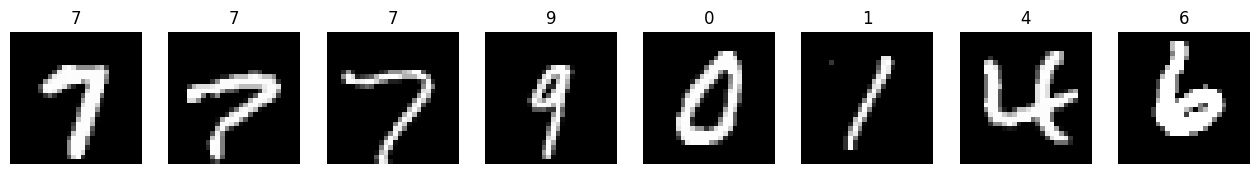

DAE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=784, bias=True)
)
[Época 1/10] Loss: 0.1533
[Época 2/10] Loss: 0.0688
[Época 3/10] Loss: 0.0557
[Época 4/10] Loss: 0.0497
[Época 5/10] Loss: 0.0458
[Época 6/10] Loss: 0.0428
[Época 7/10] Loss: 0.0404
[Época 8/10] Loss: 0.0383
[Época 9/10] Loss: 0.0365
[Época 10/10] Loss: 0.0350


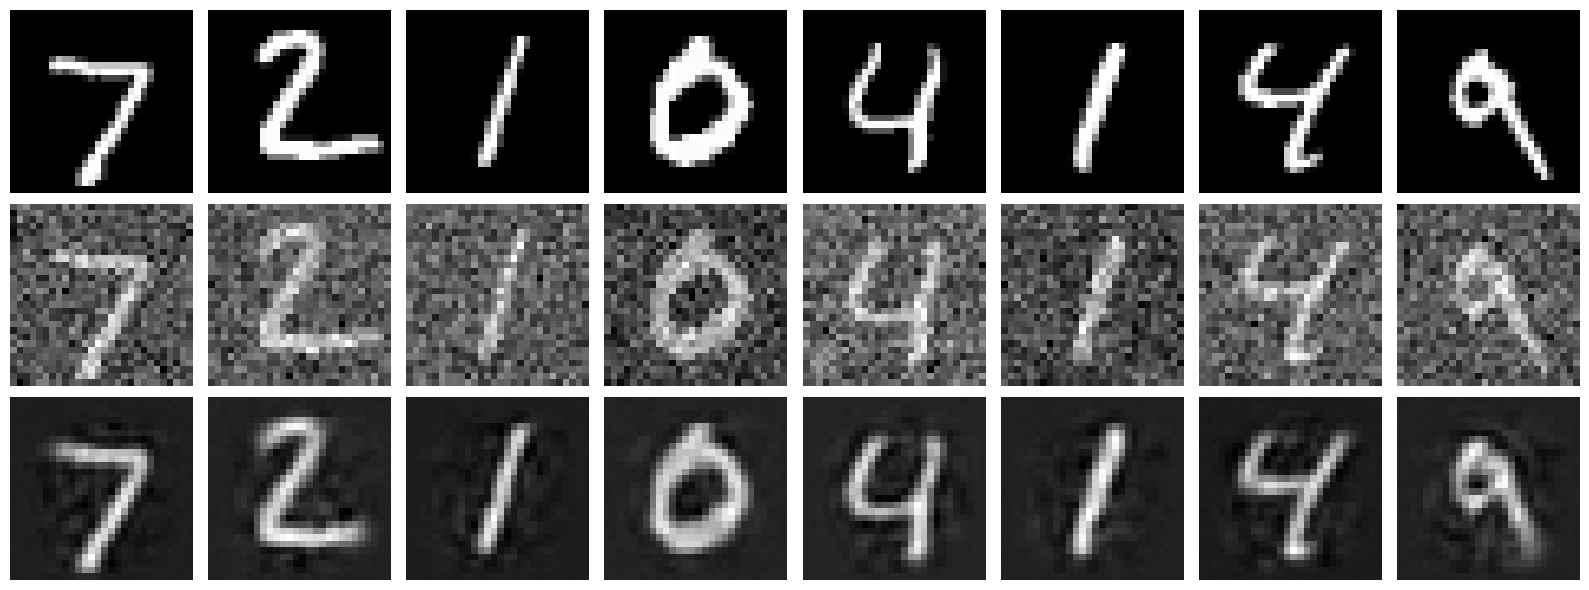

In [ ]:
# ============================================================
# Notebook 1 — Denoising Autoencoder (DAE) em MNIST
# Versão Estudante (com TODOs)
# ============================================================

# -------------------- Setup --------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# -------------------- Dataset MNIST --------------------
def get_mnist_loaders(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),            # [0,1]
        transforms.Lambda(lambda x: x*2-1)  # [-1,1] (opcional, pode remover)
    ])

    train_dataset = datasets.MNIST(
        root=".", train=True, download=True, transform=transform
    )
    test_dataset = datasets.MNIST(
        root=".", train=False, download=True, transform=transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


train_loader, test_loader = get_mnist_loaders(batch_size=128)
print("Batches treino:", len(train_loader), "| Batches teste:", len(test_loader))


# -------------------- Visualização Rápida --------------------
def show_batch(loader, n=8):
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    x_plot = (x + 1) / 2.0  # voltar para [0,1] para plot (se usamos [-1,1])

    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        axes[i].imshow(x_plot[i, 0].numpy(), cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(int(y[i]))
    plt.show()


show_batch(train_loader, n=8)


# -------------------- Função de Ruído (TODO) --------------------
def add_noise(x, sigma=0.5):
    """
    Adiciona ruído Gaussiano à imagem.
    x: tensor (B, 1, 28, 28), assumindo em [-1,1] ou [0,1]
    sigma: desvio padrão do ruído (float)
    Retorna: x_noisy
    """
    # TODO 1: implemente ruído gaussiano com std = sigma
    # Dica: use torch.randn_like(x)
    x_noisy = x + torch.randn_like(x) * sigma
    return x_noisy


# -------------------- Modelo DAE (MLP) --------------------
class DAE(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x_noisy):
        """
        x_noisy: (B, 1, 28, 28) ou (B, 784)
        Retorna: x_hat (B, 1, 28, 28)
        """
        # TODO 2: implemente o forward do MLP
        # 1) achatar a imagem
        # 2) aplicar ReLU nas duas primeiras camadas
        # 3) saída da fc3
        # 4) reshapar de volta para (B, 1, 28, 28)
        if x_noisy.dim() == 4:
            x_flat = x_noisy.view(x_noisy.size(0), -1)
        else:
            x_flat = x_noisy

        out = torch.sigmoid(self.fc2(torch.sigmoid(self.fc1(x_flat))))
        out = self.fc3(out)
        x_hat = out.view(x_noisy.size(0), 1, 28, 28)
        return x_hat


model = DAE().to(device)
print(model)


# -------------------- Treino do DAE --------------------
def train_dae(model, train_loader, epochs=5, lr=1e-3, sigma=0.5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        num_batches = 0

        for x, _ in train_loader:
            x = x.to(device)
            # gerar x_noisy usando add_noise
            x_noisy = add_noise(x, sigma=sigma)
            x_hat = model(x_noisy)
            loss = F.mse_loss(x_hat, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / max(1, num_batches)
        history.append(avg_loss)
        print(f"[Época {epoch}/{epochs}] Loss: {avg_loss:.4f}")

    return history


# Descomente para treinar:
history = train_dae(model, train_loader, epochs=10, lr=1e-3, sigma=0.5)


# -------------------- Visualização de Reconstruções --------------------
@torch.no_grad()
def show_denoising_examples(model, loader, sigma=0.5, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    x_noisy = add_noise(x, sigma=sigma)
    x_hat = model(x_noisy)

    # Converter de [-1,1] para [0,1] (se for o caso)
    def to_01(z):
        return (z + 1) / 2.0

    x_plot = to_01(x.cpu())
    x_noisy_plot = to_01(x_noisy.cpu())
    x_hat_plot = to_01(x_hat.cpu())

    fig, axes = plt.subplots(3, n, figsize=(n*2, 6))
    for i in range(n):
        axes[0, i].imshow(x_plot[i, 0].numpy(), cmap="gray")
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_ylabel("Original", fontsize=12)

        axes[1, i].imshow(x_noisy_plot[i, 0].numpy(), cmap="gray")
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_ylabel("Noisy", fontsize=12)

        axes[2, i].imshow(x_hat_plot[i, 0].numpy(), cmap="gray")
        axes[2, i].axis("off")
        if i == 0:
            axes[2, i].set_ylabel("Denoised", fontsize=12)

    plt.tight_layout()
    plt.show()

# Depois de treinar:
show_denoising_examples(model, test_loader, sigma=0.5, n=8)


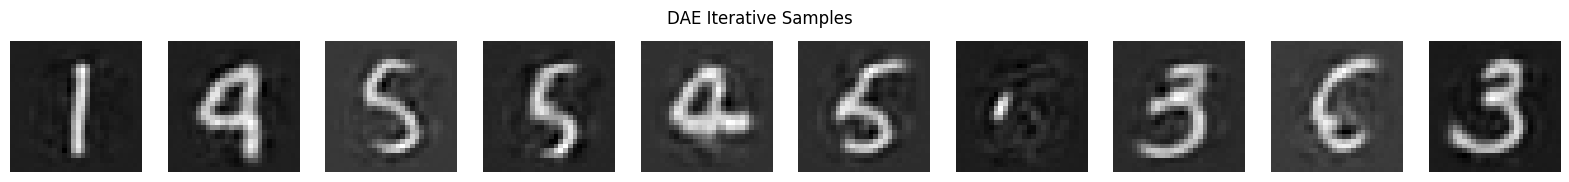

In [ ]:
@torch.no_grad()
def sample_from_dae(model, steps=20, n=16, sigma=0.5):
    """
    Gera amostras a partir do DAE usando denoising iterativo:
    1. Começa com ruído puro
    2. Aplica o DAE repetidamente
    3. Cada passo remove um pouco de ruído

    Isso NÃO é um gerador "verdadeiro" como um VAE/DDPM,
    mas demonstra visualmente a habilidade de denoising.
    """
    model.eval()

    # inicializa com ruído puro
    x = torch.randn(n, 1, 28, 28, device=device)

    for i in range(steps):
        # o DAE tenta "puxar" x para o manifold dos dados
        x = model(x)

    return x

# ============================================================
# Função auxiliar show_images — para visualizar apenas imagens
# ============================================================

def show_images(x, n=16, title=""):
    """
    x: tensor (B, 1, 28, 28) em [-1,1] ou [0,1]
    n: número de imagens a mostrar
    """
    x = x[:n].detach().cpu()

    # converter [-1,1] → [0,1] se necessário
    if x.min() < 0:
        x_plot = (x + 1) / 2.0
    else:
        x_plot = x

    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2))
    for i in range(n):
        axes[i].imshow(x_plot[i, 0], cmap="gray")
        axes[i].axis("off")
    if title:
        fig.suptitle(title)
    plt.show()



# ------------------------------------------------------------
# VISUALIZAR AMOSTRAS DO DAE
# ------------------------------------------------------------

# Gere 16 amostras
samples = sample_from_dae(model, steps=500, n=16, sigma=0.5)

# visualize
show_images(samples, n=10, title="DAE Iterative Samples")